# Pipeline for the anomaly detection on the SKAB using Convolutional Autoencoder

Details regarding the SKAB one can find in the [SKAB repository](https://github.com/waico/SKAB).

In [1]:
# libraries importing
import sys
import warnings

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

sys.path.append("..")
from core.Conv_AE_pytorch import Conv_AE
from core.metrics import chp_score
from core.utils import create_sequences, load_preprocess_skab, plot_results

warnings.filterwarnings("ignore", category=UserWarning)
import os
from core.plot_learning_curve import plot_learning_curve

## Data

In [2]:
Xy_traintest_list = load_preprocess_skab()

## Method

### Method initialization

In [3]:
# hyperparameters selection
N_STEPS = 60
Q = 0.999  # quantile for upper control limit (UCL) selection

In [4]:
# model defining
model = Conv_AE()

### Method fitting and applying

In [5]:
# inference
predicted_outlier, predicted_cp = [], []
true_outlier, true_cp = [], []
all_scores = []
for X_train, X_test, y_train, y_test in Xy_traintest_list:
    # scaler init and fitting
    StSc = StandardScaler()
    StSc.fit(X_train)

    # convert into input/output
    X = create_sequences(StSc.transform(X_train), N_STEPS)

    # model fitting
    model.fit(X)

    # results predicting
    residuals = pd.Series(
        np.sum(np.mean(np.abs(X - model.predict(X)), axis=1), axis=1)
    )
    UCL = residuals.quantile(Q) * 4 / 3

    # results predicting
    X = create_sequences(StSc.transform(X_test), N_STEPS)
    cnn_residuals = pd.Series(
        np.sum(np.mean(np.abs(X - model.predict(X)), axis=1), axis=1)
    )

    all_scores.append(cnn_residuals)

    # data i is an anomaly if samples [(i - timesteps + 1) to (i)] are anomalies
    anomalous_data = cnn_residuals > UCL
    anomalous_data_indices = []
    for data_idx in range(N_STEPS - 1, len(X) - N_STEPS + 1):
        if np.all(anomalous_data[data_idx - N_STEPS + 1 : data_idx]):
            anomalous_data_indices.append(data_idx)

    prediction = pd.Series(data=0, index=X_test.index)
    prediction.iloc[anomalous_data_indices] = 1

    # predicted outliers saving
    predicted_outlier.append(prediction)

    # predicted CPs saving
    prediction_cp = abs(prediction.diff())
    prediction_cp.iloc[0] = prediction.iloc[0]
    predicted_cp.append(prediction_cp)

    true_outlier.append(y_test["anomaly"])
    true_cp.append(y_test["changepoint"])

Epoch 1/40 | train=0.8113 | val=0.7655
Epoch 2/40 | train=0.7688 | val=0.7293
Epoch 3/40 | train=0.7321 | val=0.6855
Epoch 4/40 | train=0.6893 | val=0.6526
Epoch 5/40 | train=0.6547 | val=0.6197
Epoch 6/40 | train=0.6203 | val=0.5955
Epoch 7/40 | train=0.5948 | val=0.5742
Epoch 8/40 | train=0.5711 | val=0.5451
Epoch 9/40 | train=0.5397 | val=0.5094
Epoch 10/40 | train=0.5057 | val=0.4755
Epoch 11/40 | train=0.4727 | val=0.4424
Epoch 12/40 | train=0.4396 | val=0.4128
Epoch 13/40 | train=0.4105 | val=0.3819
Epoch 14/40 | train=0.3801 | val=0.3545
Epoch 15/40 | train=0.3517 | val=0.3292
Epoch 16/40 | train=0.3261 | val=0.3057
Epoch 17/40 | train=0.3022 | val=0.2829
Epoch 18/40 | train=0.2794 | val=0.2622
Epoch 19/40 | train=0.2586 | val=0.2409
Epoch 20/40 | train=0.2391 | val=0.2228
Epoch 21/40 | train=0.2221 | val=0.2106
Epoch 22/40 | train=0.2061 | val=0.1913
Epoch 23/40 | train=0.1900 | val=0.1834
Epoch 24/40 | train=0.1804 | val=0.1720
Epoch 25/40 | train=0.1706 | val=0.1619
Epoch 26/

### Results visualization

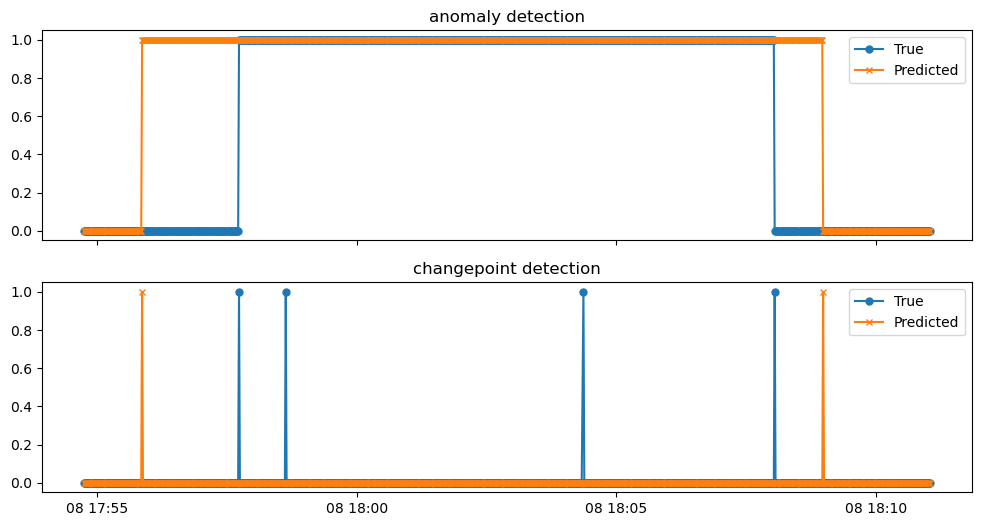

In [6]:
# [donotremove]
plot_results(
    (true_outlier[1], predicted_outlier[1]),
    (true_cp[1], predicted_cp[1]),
)

## Evaluation (metrics calculation)

In [7]:
import pickle

pickle.dump(
    predicted_outlier,
    open(f"../results/results-{model.__class__.__name__}.pkl", "wb"),
)

Zapisano: images/lc_conv_ae.png


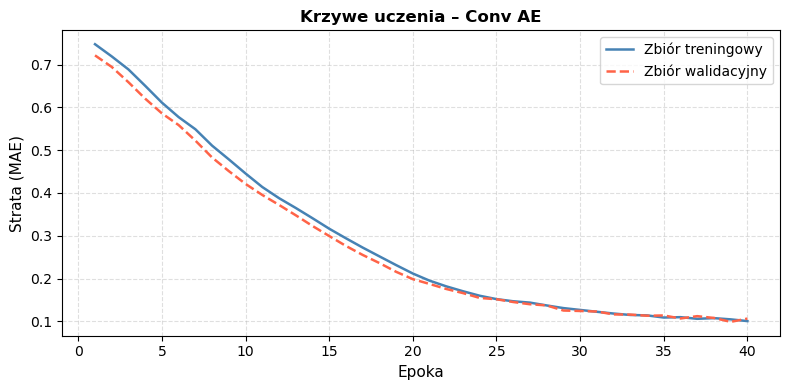

In [8]:
os.makedirs("images", exist_ok=True)
plot_learning_curve(
    model,
    'Conv AE',
    save_path='images/lc_conv_ae.png'
)

In [9]:
# --- KROK 2: Zapis scores/labels ---
import numpy as np
from pathlib import Path
Path('results').mkdir(exist_ok=True)
np.save('results/scores_conv_ae.npy', np.array(all_scores, dtype=object), allow_pickle=True)
np.save('results/labels_conv_ae.npy', np.array(true_outlier, dtype=object), allow_pickle=True)
print("OK: Conv AE zapisany")

OK: Conv AE zapisany


In [10]:
import numpy as np
from pathlib import Path
Path('results').mkdir(exist_ok=True)
np.save('results/scores_vanilla_ae.npy', np.array(all_scores, dtype=object), allow_pickle=True)
np.save('results/labels_vanilla_ae.npy', np.array(true_outlier, dtype=object), allow_pickle=True)
print("OK: Vanilla AE zapisany")

OK: Vanilla AE zapisany


### Binary classification (outlier detection) metrics

In [11]:
# [donotremove]
# binary classification metrics calculation
binary = chp_score(true_outlier, predicted_outlier, metric="binary")

False Alarm Rate 29.01 %
Missing Alarm Rate 8.62 %
F1 metric 0.84


### Changepoint detection metrics

In [12]:
# [donotremove]
# average detection delay metric calculation
add = chp_score(
    true_cp,
    predicted_cp,
    metric="average_time",
    window_width="60s",
    anomaly_window_destination="righter",
)

Amount of true anomalies 127
A number of missed CPs = 81
A number of FPs = 32
Average time 0 days 00:00:38.739130


In [13]:
# [donotremove]
# nab metric calculation
nab = chp_score(
    true_cp,
    predicted_cp,
    metric="nab",
    window_width="60s",
    anomaly_window_destination="righter",
)

Standard  -  21.36
LowFP  -  18.64
LowFN  -  26.32


In [18]:
min_len = min(len(all_scores[0]), len(true_outlier[0]))

all_scores = [s[:min_len] for s in all_scores]
true_outlier = [l[:min_len] for l in true_outlier]

Zapisano ROC: images/roc_conv_ae.png


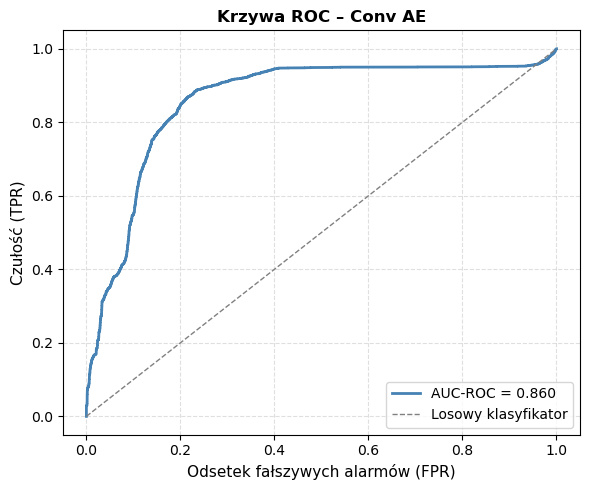

Zapisano PR: images/pr_conv_ae.png


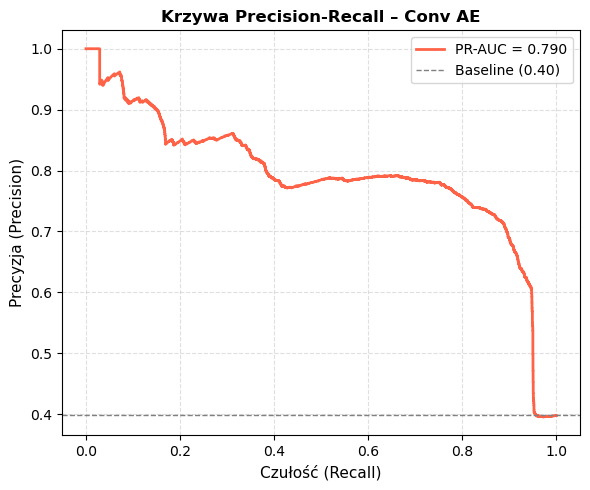


Model:    Conv AE
AUC-ROC:  0.8597
PR-AUC:   0.7901
MCC:      0.6404  (próg optymalny = 2.6292)



In [19]:
metrics_conv = plot_roc_pr(
    scores_list = all_scores,
    labels_list = true_outlier,
    model_name  = 'Conv AE',
    save_roc    = 'images/roc_conv_ae.png',
    save_pr     = 'images/pr_conv_ae.png',
)

In [20]:
print(len(all_scores))
print(type(all_scores[0]))
print(all_scores[0][:5])

34
<class 'pandas.Series'>
0    1.661987
1    1.621152
2    1.621718
3    1.610076
4    1.587363
dtype: float64
